# Residual diagnostics on scaling law fits

In this notebook, you can play with point fits to the training experiment data and discover for yourself that the new parameter $\alpha_2$ is required to represent the stucture in our data.


In [4]:
import os, sys

# Repo root on the path (for `nano_llama` and `scaling_law`), from either cwd.
_HERE = os.getcwd()
for _cand in (_HERE, os.path.dirname(_HERE)):
    if os.path.isdir(os.path.join(_cand, "nano_llama")) and _cand not in sys.path:
        sys.path.insert(0, _cand)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FixedLocator
plt.style.use("default")

import scaling_law as est
from scaling_law import data_loading as dl

# ---- source + screen -------------------------------------------------------------- # <-- SET
PROCESSED_DIR = "/home/trevor/fht_summary_data/raw_loss_data"
K = None                     # None -> require the data to hold exactly one k_train and use it
MAX_P = None                 # keep cohorts with p_train <= MAX_P; None keeps all


SCREEN = dict(
    max_ceiling_frac=1.0,
    min_ne_frac=0.4,
    min_tpp=5,
)

# change this to None to enable fitting of the new parameter
FIX_ALPHA2 = 0.0

# you can also try adding curvature to the data part (hint: it doesn't work)
FIX_BETA2 = None

# changing or fitting E cannot get rid of the curvature (but try for yourself)
FIX_E = 1.5

N0, D0 = est.N0_DEFAULT, est.D0_DEFAULT
# -----------------------------------------------------------------------------------

cohorts = dl.load_matched_results(PROCESSED_DIR, k=K)
k_used = float(cohorts[next(iter(cohorts))][0].k_train)
if MAX_P is not None:
    cohorts = {p: v for p, v in cohorts.items() if p <= MAX_P}
cohorts, filt = dl.filter_cohorts(cohorts, **SCREEN)
dl.print_filter_report(filt, **SCREEN)

arr = {}
for p in sorted(cohorts):
    a = dl.eval_cohort_arrays(cohorts[p])
    a["eval_se"] = np.array([r.eval_se for r in cohorts[p]], dtype=float)
    a["tpp"] = a["D"] / a["N"]
    arr[p] = a


_HALF_NORMAL_MEDIAN = 0.6745
run_sigma, run_cells = {}, {}
for p, a in arr.items():
    cells = {}
    for i in range(a["L"].size):
        cells.setdefault((str(a["size"][i]), float(a["D"][i])), []).append(np.log(a["L"][i]))
    reps = [v for v in cells.values() if len(v) >= 2]
    if reps:
        med_n = int(np.median([len(v) for v in reps]))
        run_sigma[p] = float(np.median([np.std(v, ddof=1) for v in reps])) / (
            _HALF_NORMAL_MEDIAN if med_n == 2 else 1.0)
    else:
        run_sigma[p] = float(np.median(a["eval_se"] / a["L"]))    # no replicates -> eval SE only
    run_cells[p] = len(reps)

P_VALUES = np.array(sorted(arr), dtype=float)
P0 = float(P_VALUES.min())
_pnorm = plt.Normalize(vmin=P_VALUES.min(), vmax=P_VALUES.max())
_pcmap = LinearSegmentedColormap.from_list(
    "p_ramp", plt.get_cmap("viridis")(np.linspace(0.0, 0.88, 256)))
cohort_color = {p: _pcmap(_pnorm(p)) for p in P_VALUES}
p_mappable = plt.cm.ScalarMappable(norm=_pnorm, cmap=_pcmap)


def p_colorbar(fig, ax, label=r"training fault  $p_\mathrm{hw}$", **kw):
    cb = fig.colorbar(p_mappable, ax=ax, **kw)
    cb.set_label(label, fontsize=9)
    cb.ax.yaxis.set_minor_locator(FixedLocator(P_VALUES))
    cb.ax.tick_params(which="minor", length=3.5, width=0.8)
    return cb


fits, diags = {}, {}
for p, a in arr.items():
    fits[p], diags[p] = est.fit_report(a["N"], a["D"], a["L"], fix_E=FIX_E,
                                       fix_alpha2=FIX_ALPHA2, fix_beta2=FIX_BETA2, N0=N0, D0=D0)

res, fam = {}, {}
for p, a in arr.items():
    res[p] = np.log(fits[p].predict(a["N"], a["D"])) - np.log(a["L"])
    g = {}
    for i, sz in enumerate(a["size"]):
        g.setdefault(str(sz), []).append(i)
    fam[p] = {s: np.array(ix) for s, ix in sorted(g.items())}

print(f"\n{sum(len(a['L']) for a in arr.values())} models across {len(arr)} cohorts, "
      f"k_train = {k_used:g}, fit on N (total params) with E free and no N ceiling")
_nc = np.array([run_cells[p] for p in sorted(arr)])
print(f"run-to-run floor: median {np.median([run_sigma[p] for p in sorted(arr)]):.4f} in log units, "
      f"from {_nc.sum()} replicate cells ({_nc.min()}-{_nc.max()} per cohort)"
      + ("  !! some cohorts have NO replicates and fall back to the eval SE" if _nc.min() == 0 else ""))
print(f"pivots: N0 = {N0:.4g}, D0 = {D0:.4g}   |   alpha2 "
      f"{'FREE' if FIX_ALPHA2 is None else f'pinned at {FIX_ALPHA2:g}'}   |   beta2 "
      f"{'FREE' if FIX_BETA2 is None else f'pinned at {FIX_BETA2:g}'}")

run filter: keep L < 1 ln(vocab), tokens/total-param >= 5, non-emb params >= 0.4  ->  dropped 1156 run(s) across 17 cohort(s)  (816 by min_ne_frac, 340 by min_tpp)
   cohort   kept  dropped                     TPP range               L max         ne_frac min
-----------------------------------------------------------------------------------------------
        0    124       68                2-320 -> 5-320      7.144 -> 5.276      0.092 -> 0.421
    0.005    123       68                2-320 -> 5-320      7.159 -> 5.293      0.092 -> 0.421
     0.01    124       68                2-320 -> 5-320      7.145 -> 5.305      0.092 -> 0.421
    0.015    123       68                2-320 -> 5-320      7.169 -> 5.275      0.092 -> 0.421
     0.02    122       68                2-320 -> 5-320      7.173 -> 5.308      0.092 -> 0.421
    0.025    124       68                2-320 -> 5-320      7.152 -> 5.319      0.092 -> 0.421
     0.03    124       68                2-320 -> 5-320      7.174 -

_## 1. The fits, and did they converge

`n_at_opt` is how many of the multi-start initialisations reached the winning objective. One is a
warning: it means the optimum was found once and there is nothing corroborating it. `E share` is the
median fraction of the predicted loss the floor term carries — if it is near zero the floor is not
being measured by the data, it is being extrapolated off the end of the ladder, and its value should
not be read as a physical quantity.

In [5]:
hdr = (f"{'cohort':<10}{'n':>5}{'E':>8}{'a':>8}{'alpha1':>9}{'alpha2':>9}"
       f"{'b':>8}{'beta1':>9}{'beta2':>9}"
       f"{'RMSE_log':>10}{'R2_log':>9}{'n_at_opt':>10}{'E share':>9}")
print(hdr); print("-" * len(hdr))
summary = []
for p in sorted(arr):
    a, f, dg = arr[p], fits[p], diags[p]
    d = est.diagnostics(f, a["N"], a["D"], a["L"])
    _, sh = est.log_pred_softmax(f, *est.centred(a["N"], a["D"], N0, D0))
    e_share = float(np.median(sh[0]))
    print(f"{f'p={p:g}':<10}{a['L'].size:>5}{f.E:>8.3f}{f.a:>+8.3f}{f.alpha1:>+9.4f}"
          f"{f.alpha2:>+9.4f}{f.b:>+8.3f}{f.beta1:>+9.4f}{f.beta2:>+9.4f}"
          f"{d['rmse_log']:>10.4f}{d['r2_log']:>9.4f}"
          f"{f'{dg['n_at_optimum']}/{dg['n_starts']}':>10}{e_share:>9.2f}")
    summary.append(dict(p=p, E=f.E, alpha1=f.alpha1, alpha2=f.alpha2, beta1=f.beta1,
                        beta2=f.beta2, rmse=d["rmse_log"], e_share=e_share,
                        n_at_opt=dg["n_at_optimum"]))

_E0 = fits[P0].E
_bad = [s["p"] for s in summary if s["E"] < _E0 - 1e-9]
print(f"\nE(p) < E(0) = {_E0:.3f} in {len(_bad)} of {len(summary)} cohorts"
      + (f": {', '.join(f'{q:g}' for q in _bad)}" if _bad else ""))

cohort        n       E       a   alpha1   alpha2       b    beta1    beta2  RMSE_log   R2_log  n_at_opt  E share
-----------------------------------------------------------------------------------------------------------------
p=0         124   1.450  +0.188  +0.1780  +0.0000  +0.769  +0.4311  -0.0065    0.0067   0.9988     82/82     0.46
p=0.005     123   1.450  +0.234  +0.1723  +0.0000  +0.745  +0.4250  -0.0022    0.0074   0.9985     82/82     0.46
p=0.01      124   1.450  +0.246  +0.1744  +0.0000  +0.725  +0.4191  -0.0030    0.0080   0.9983     82/82     0.45
p=0.015     123   1.450  +0.291  +0.1694  +0.0000  +0.686  +0.4026  +0.0051    0.0070   0.9987     82/82     0.45
p=0.02      122   1.450  +0.287  +0.1711  +0.0000  +0.701  +0.4182  -0.0019    0.0081   0.9981     82/82     0.44
p=0.025     124   1.450  +0.298  +0.1728  +0.0000  +0.687  +0.4002  +0.0018    0.0079   0.9983     82/82     0.44
p=0.03      124   1.450  +0.333  +0.1653  +0.0000  +0.676  +0.3960  +0.0074    0.0085   

## 2. Residual structure across cohorts, in numbers

plots the mean residual (over seeds and D) for each model in our sweep

cohort       RMSE_log   run-run     se/L  resid/floor   TPP step  t(log N)  t(log D)    wave
--------------------------------------------------------------------------------------------
p=0            0.0067    0.0047   0.0037          1.4    -0.0034     -0.17     +1.09     2.4
p=0.005        0.0074    0.0051   0.0037          1.4    -0.0001     +1.93     +0.38     3.4
p=0.01         0.0080    0.0054   0.0036          1.5    -0.0025     +1.37     +1.35     3.7
p=0.015        0.0070    0.0046   0.0036          1.5    -0.0021     +0.08     +0.41     3.6
p=0.02         0.0081    0.0053   0.0035          1.5    -0.0043     +0.35     +1.65     3.3
p=0.025        0.0079    0.0044   0.0035          1.8    -0.0011     -0.05     -0.03     4.0
p=0.03         0.0085    0.0038   0.0035          2.2    -0.0009     +0.91     +0.50     6.5
p=0.035        0.0078    0.0056   0.0034          1.4    -0.0005     +1.34     +0.38     4.0
p=0.04         0.0082    0.0044   0.0034          1.9    -0.0007     +

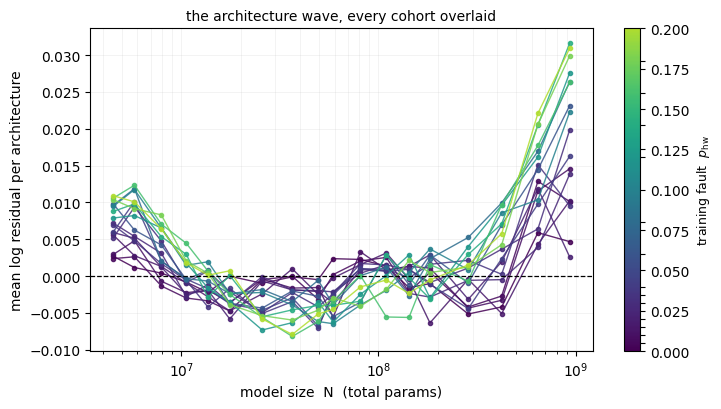

In [6]:
def arch_means(p):
    """(N, mean residual, SEM) per architecture, ascending in N."""
    a, r, g = arr[p], res[p], fam[p]
    x = np.array([a["N"][ix[0]] for ix in g.values()])
    m = np.array([np.mean(r[ix]) for ix in g.values()])
    e = np.array([np.std(r[ix], ddof=1) / np.sqrt(len(ix)) if len(ix) > 1 else np.nan
                  for ix in g.values()])
    o = np.argsort(x)
    return x[o], m[o], e[o], np.array(list(g.keys()))[o]


hdr = (f"{'cohort':<11}{'RMSE_log':>10}{'run-run':>10}{'se/L':>9}{'resid/floor':>13}"
       f"{'TPP step':>11}{'t(log N)':>10}{'t(log D)':>10}{'wave':>8}")
print(hdr); print("-" * len(hdr))
waves = {}
for p in sorted(arr):
    a, r = arr[p], res[p]
    rel_se = float(np.median(a["eval_se"] / a["L"]))
    lo, hi = a["tpp"] <= 20, a["tpp"] > 20
    step = (r[lo].mean() - r[hi].mean()) if lo.any() and hi.any() else np.nan
    def _t(x):
        """t-statistic on a linear trend of the residual in log x."""
        lx = np.log(x)
        slope = np.polyfit(lx, r, 1)[0]
        return slope / (np.std(r, ddof=2) / (np.std(lx) * np.sqrt(lx.size)))

    t, tD = _t(a["N"]), _t(a["D"])
    x, m, e, names = arch_means(p)
    waves[p] = (x, m, names)
    sig = run_sigma[p]
    print(f"{f'p={p:g}':<11}{np.sqrt(np.mean(r ** 2)):>10.4f}{sig:>10.4f}{rel_se:>9.4f}"
          f"{np.std(r, ddof=1) / sig:>13.1f}{step:>+11.4f}{t:>+10.2f}{tD:>+10.2f}"
          f"{np.ptp(m) / sig:>8.1f}")

# Is the per-architecture wave the SAME shape in every cohort? If it is, it is a property of the
# architectures rather than of the fault, and no per-cohort fit can be blamed for it.
common = sorted(set.intersection(*(set(w[2].tolist()) for w in waves.values())))
M = np.array([[waves[p][1][list(waves[p][2]).index(s)] for s in common] for p in sorted(waves)])
C = np.corrcoef(M)
iu = np.triu_indices(len(C), 1)
print(f"\narchitecture wave, cross-cohort correlation over {len(common)} shared architectures:")
print(f"  mean pairwise r = {C[iu].mean():+.3f}   (median {np.median(C[iu]):+.3f})")
print("  a high value means every cohort misfits the SAME architectures the same way -- shape the")
print("  Chinchilla form cannot express, not noise and not a fault effect.")

fig, ax = plt.subplots(figsize=(7.4, 4.2))
for p in sorted(waves):
    x, m, _ = waves[p]
    ax.plot(x, m, "o-", color=cohort_color[p], ms=3, lw=1.0, alpha=0.85)
ax.axhline(0, color="k", lw=0.9, ls="--")
ax.set_xscale("log")
ax.set_xlabel("model size  N  (total params)")
ax.set_ylabel("mean log residual per architecture")
ax.set_title("the architecture wave, every cohort overlaid", fontsize=10)
ax.grid(alpha=0.25, which="both", lw=0.4)
p_colorbar(fig, ax)
fig.tight_layout(); plt.show()

## 3. The residual panels, one figure per cohort

Plots much more detailed residual information

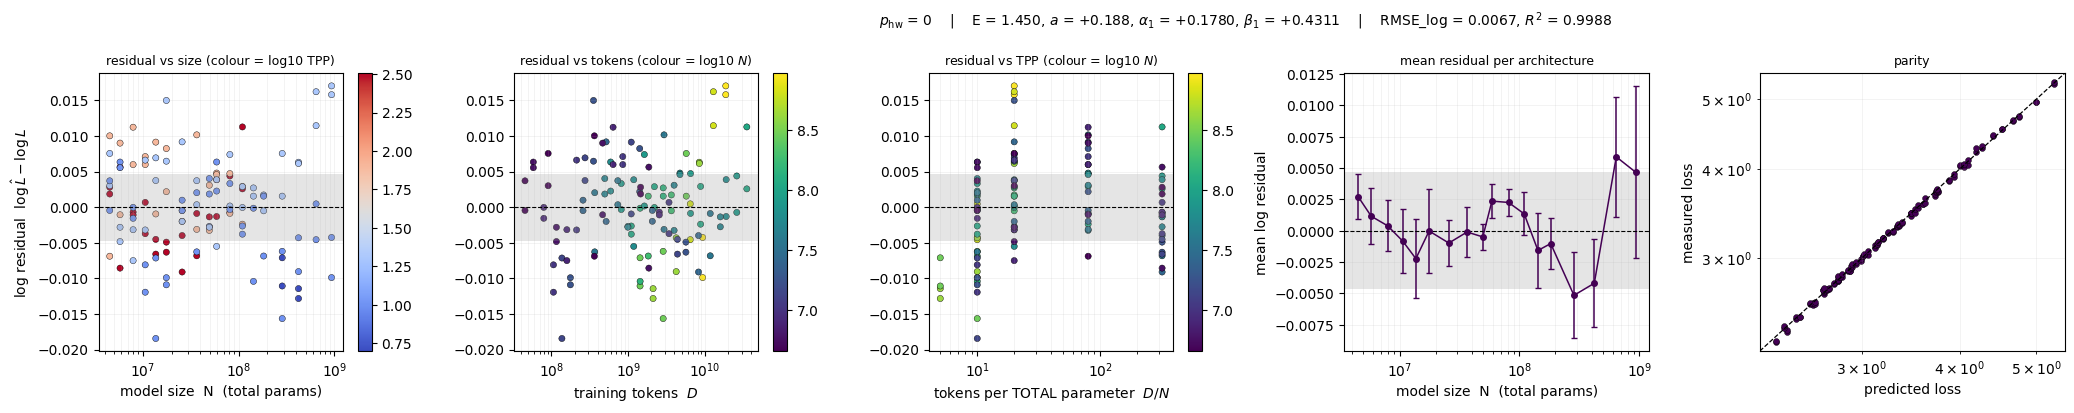

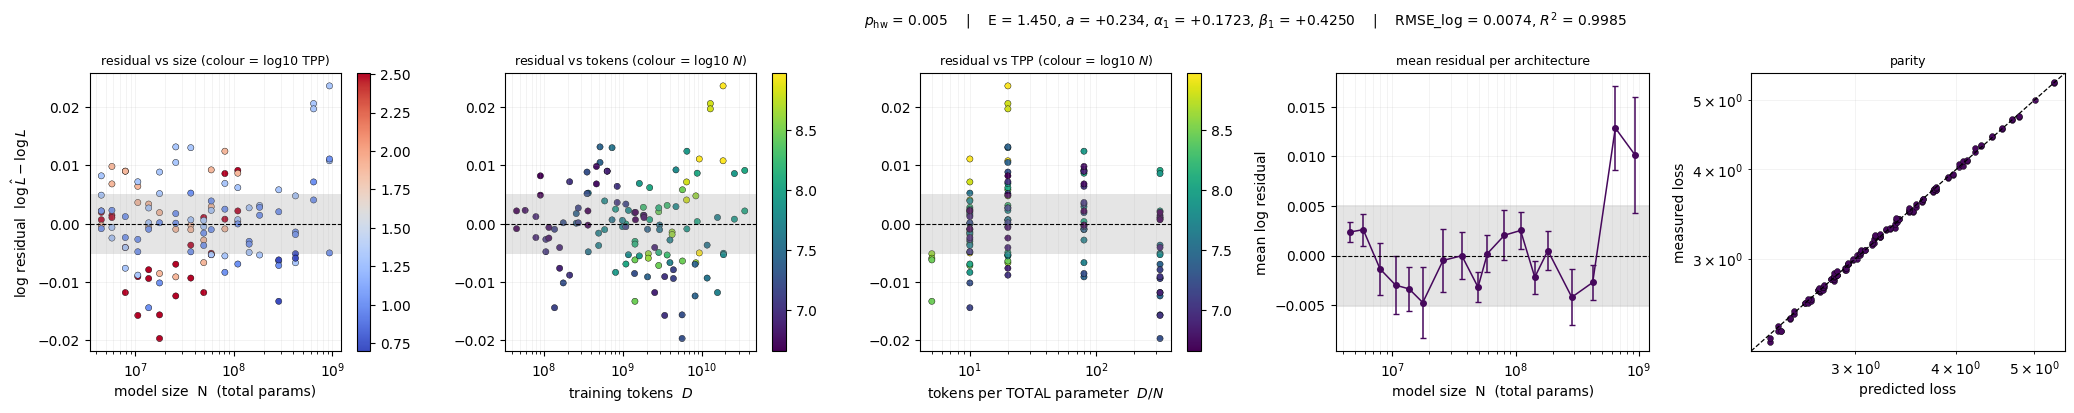

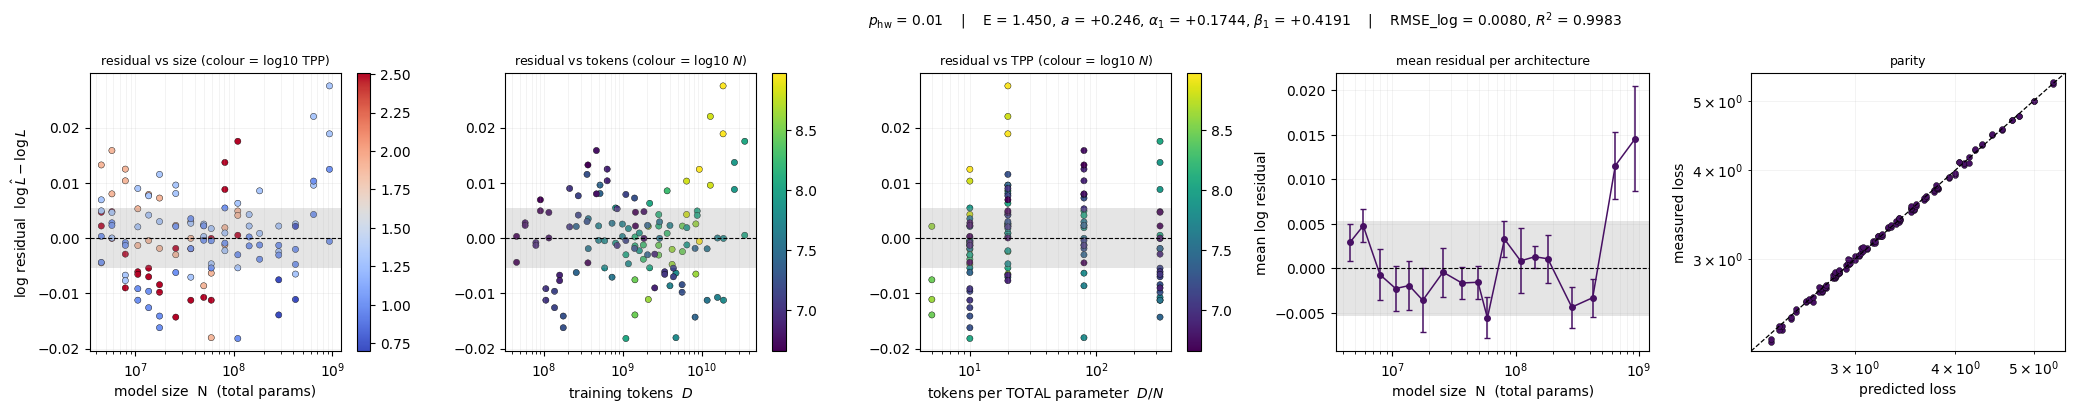

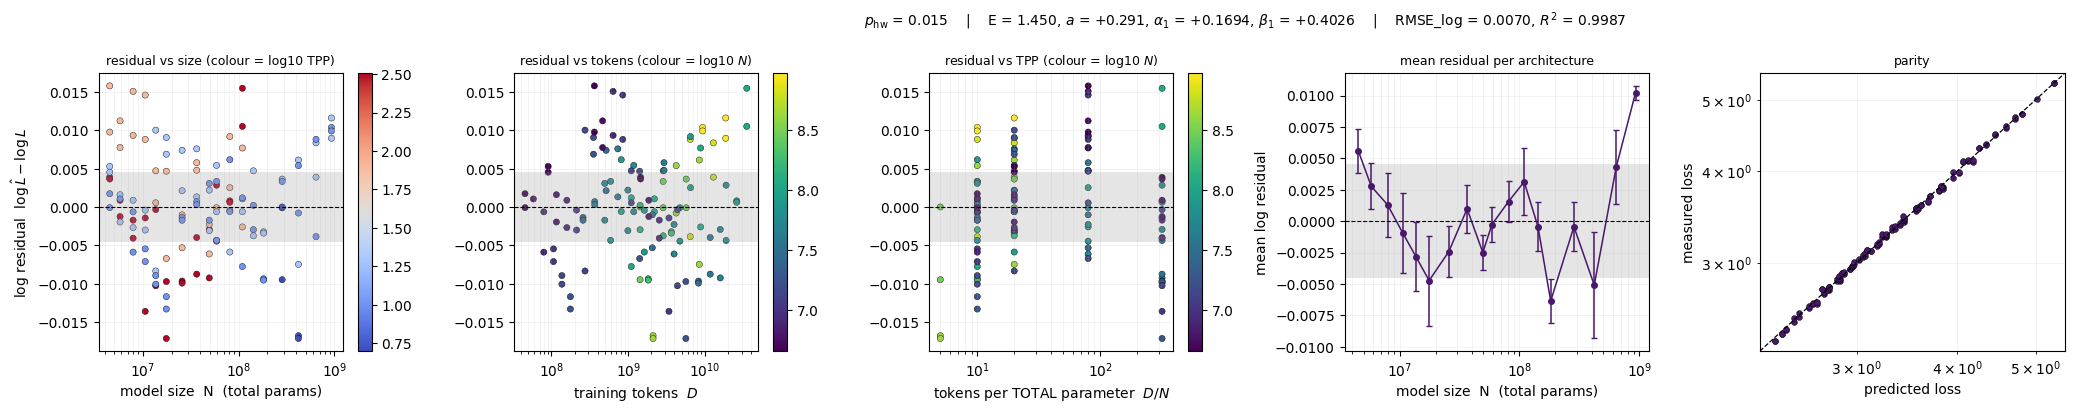

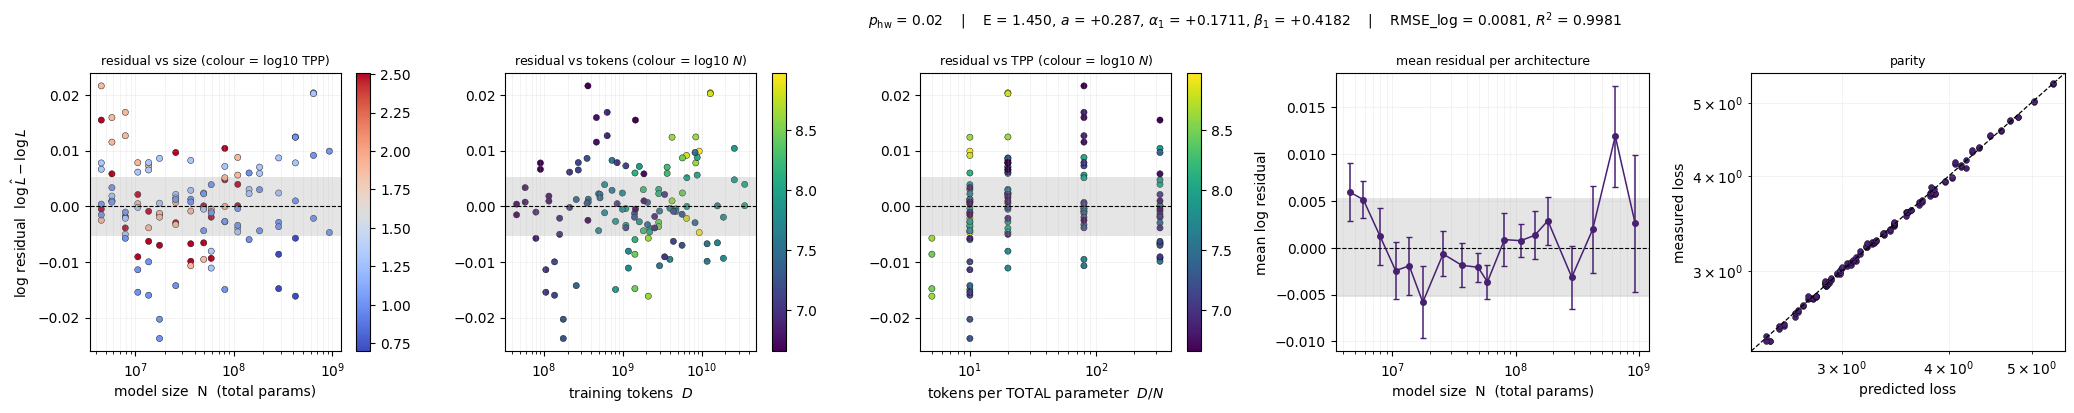

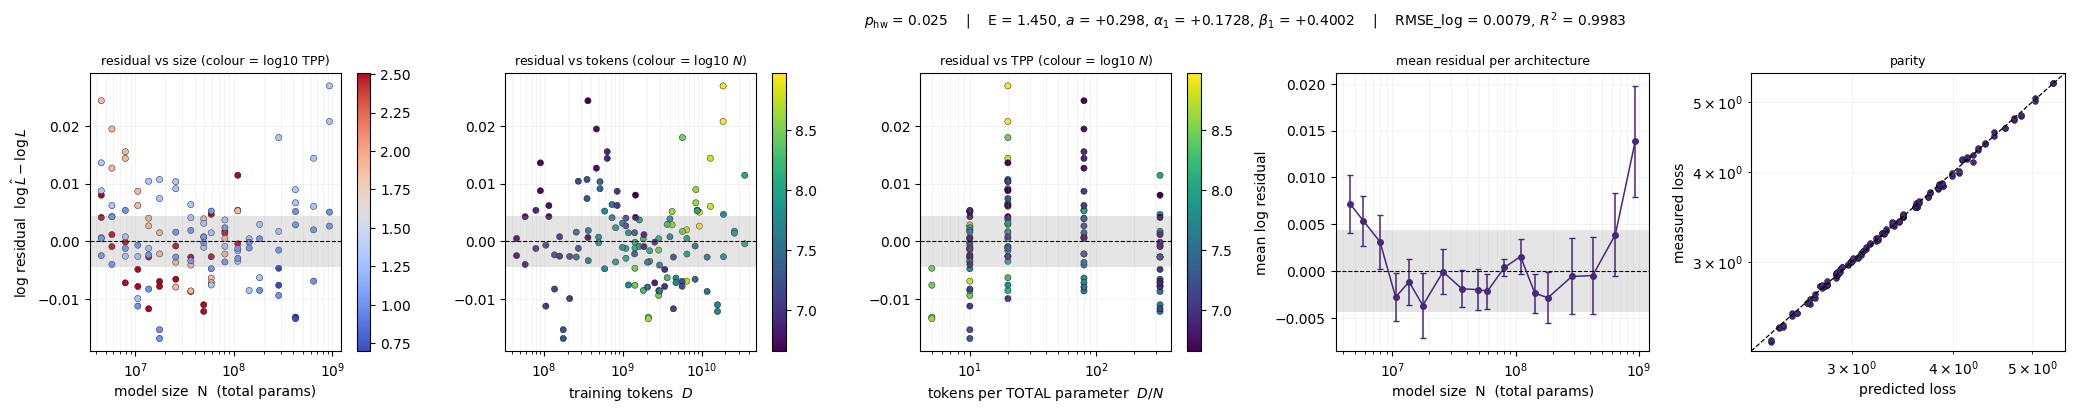

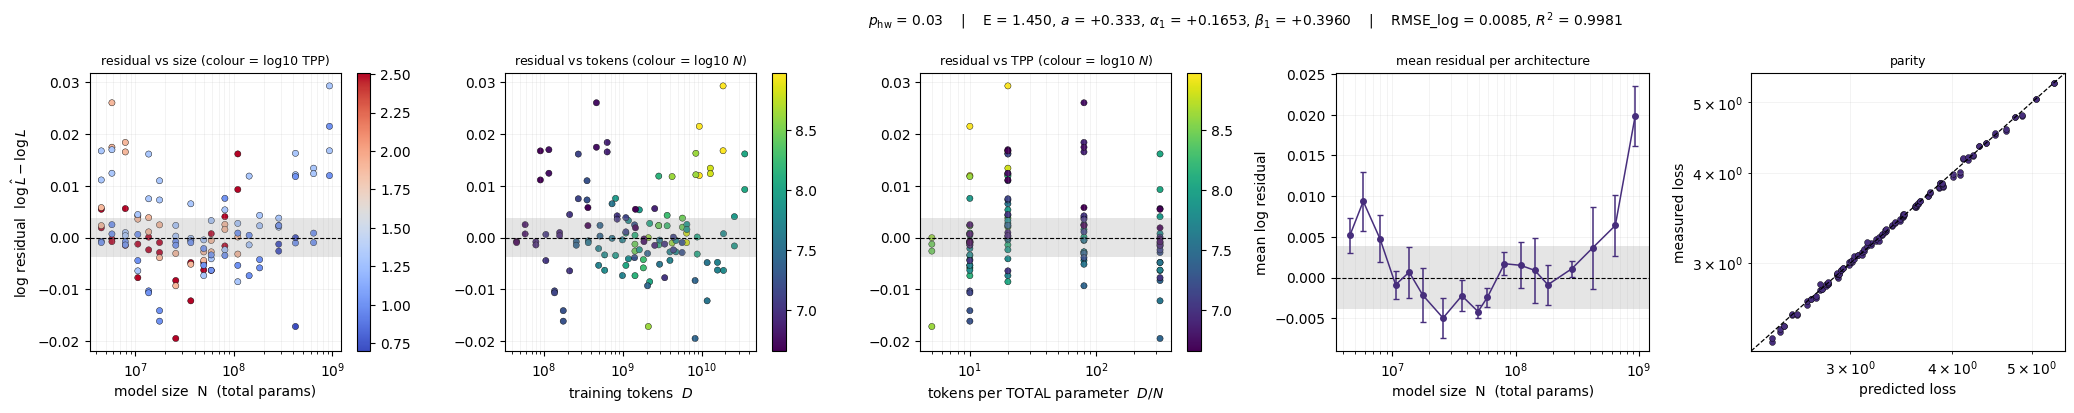

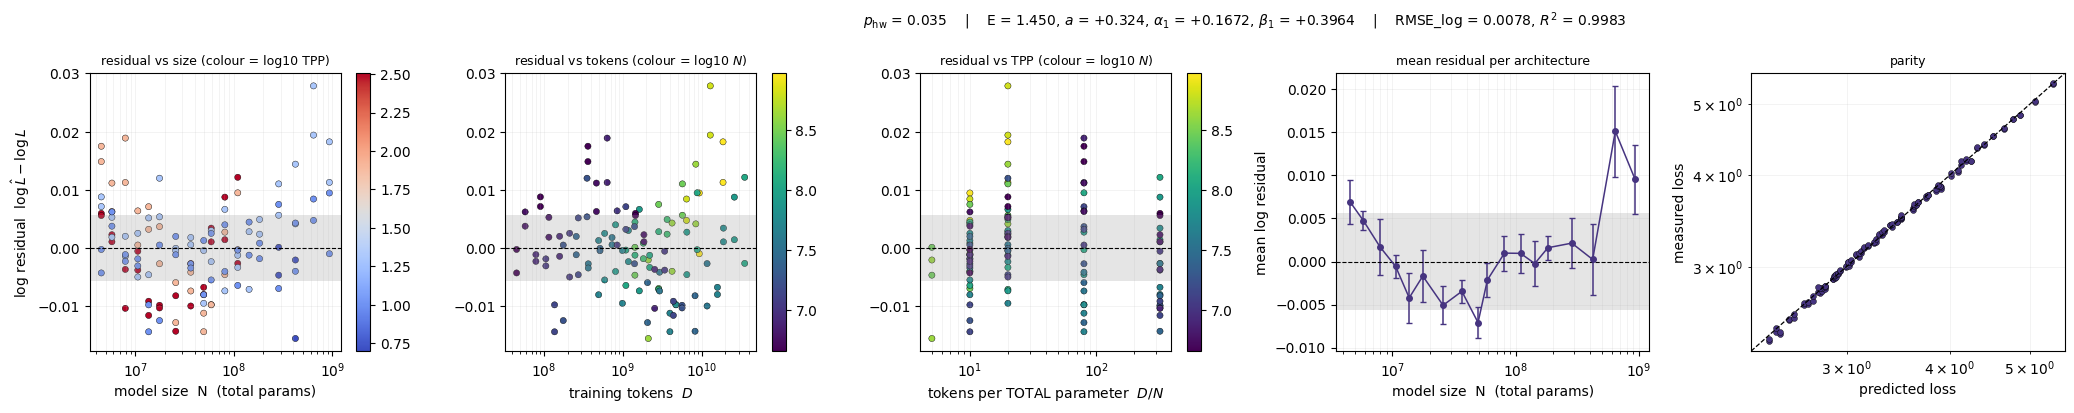

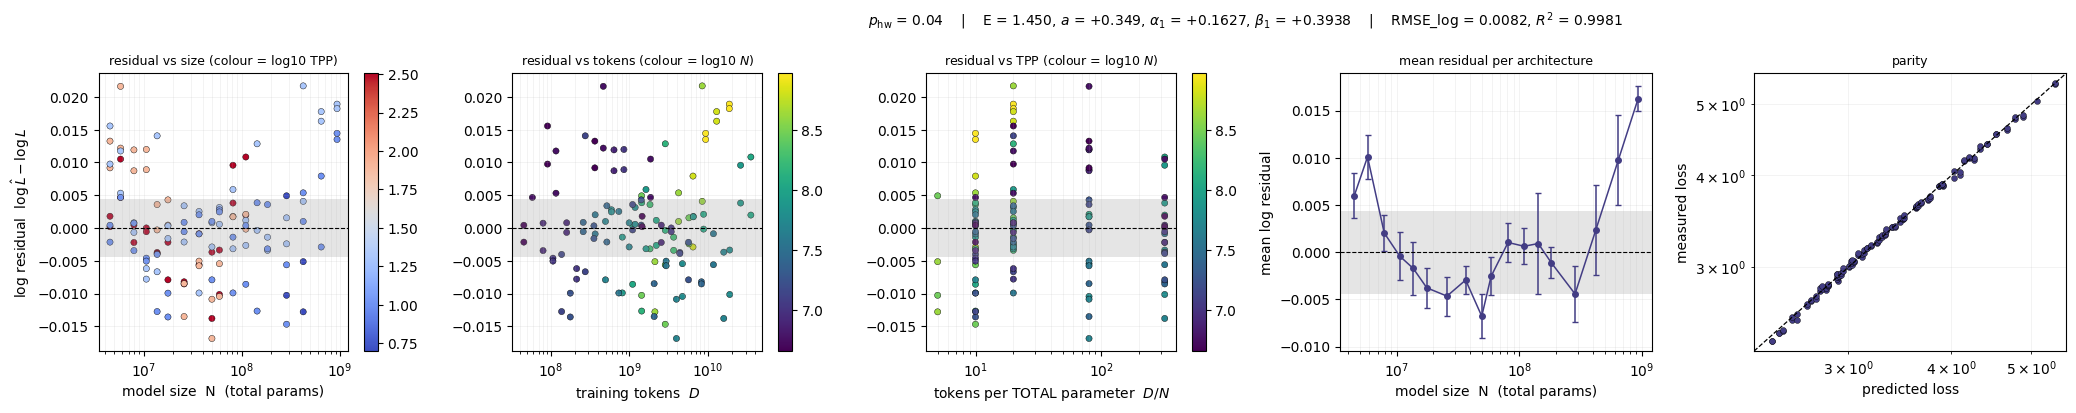

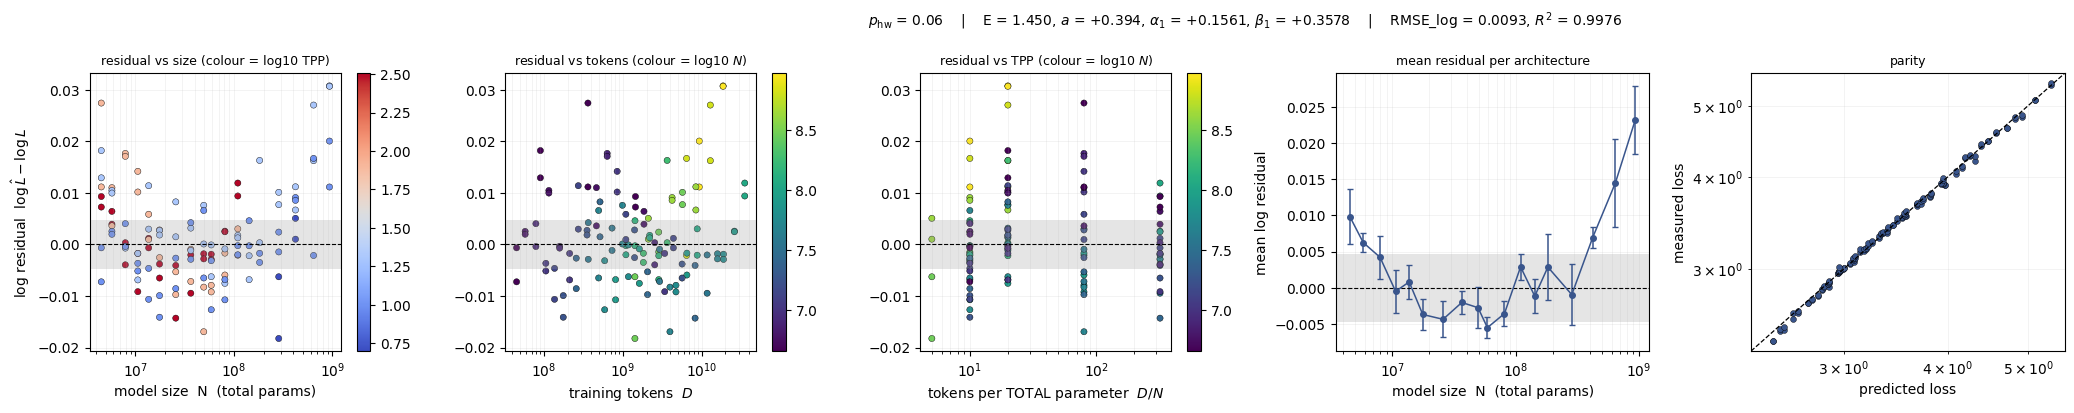

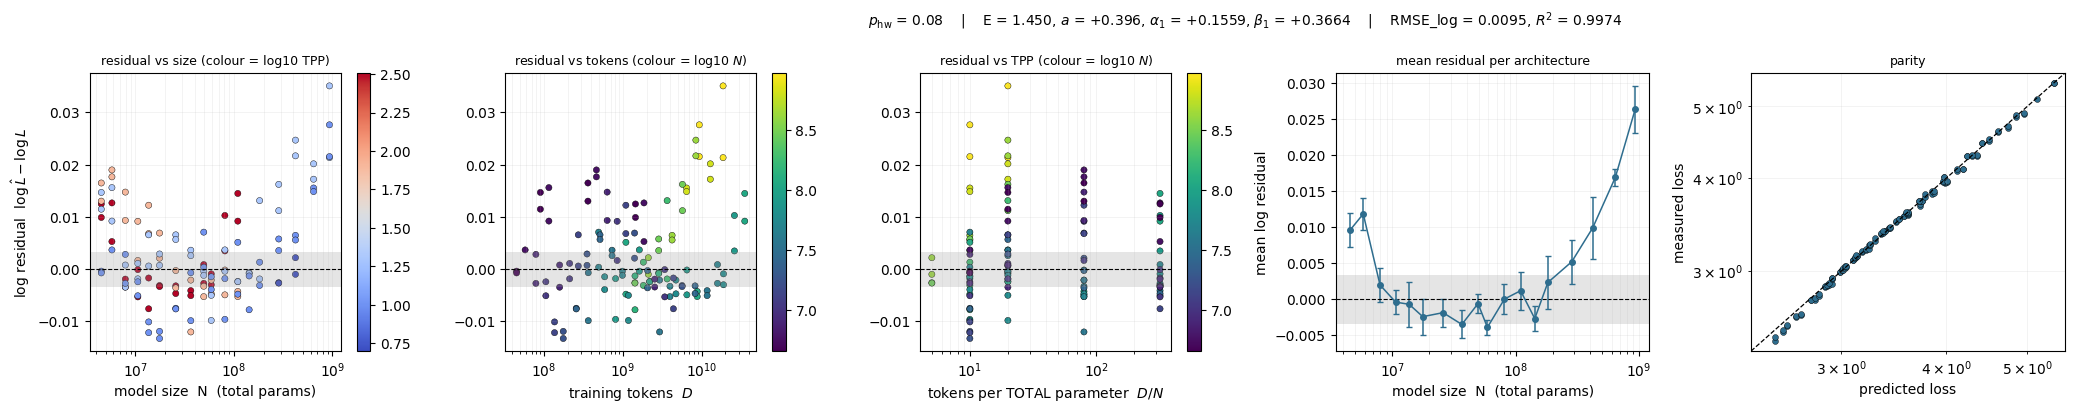

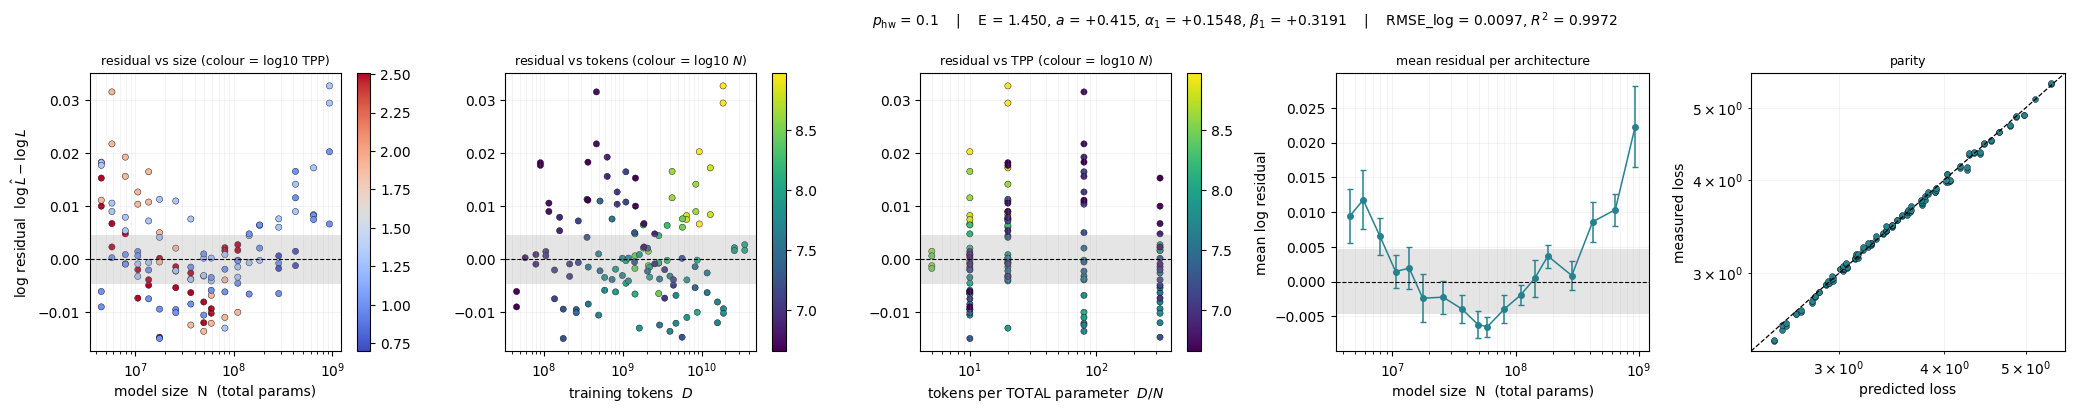

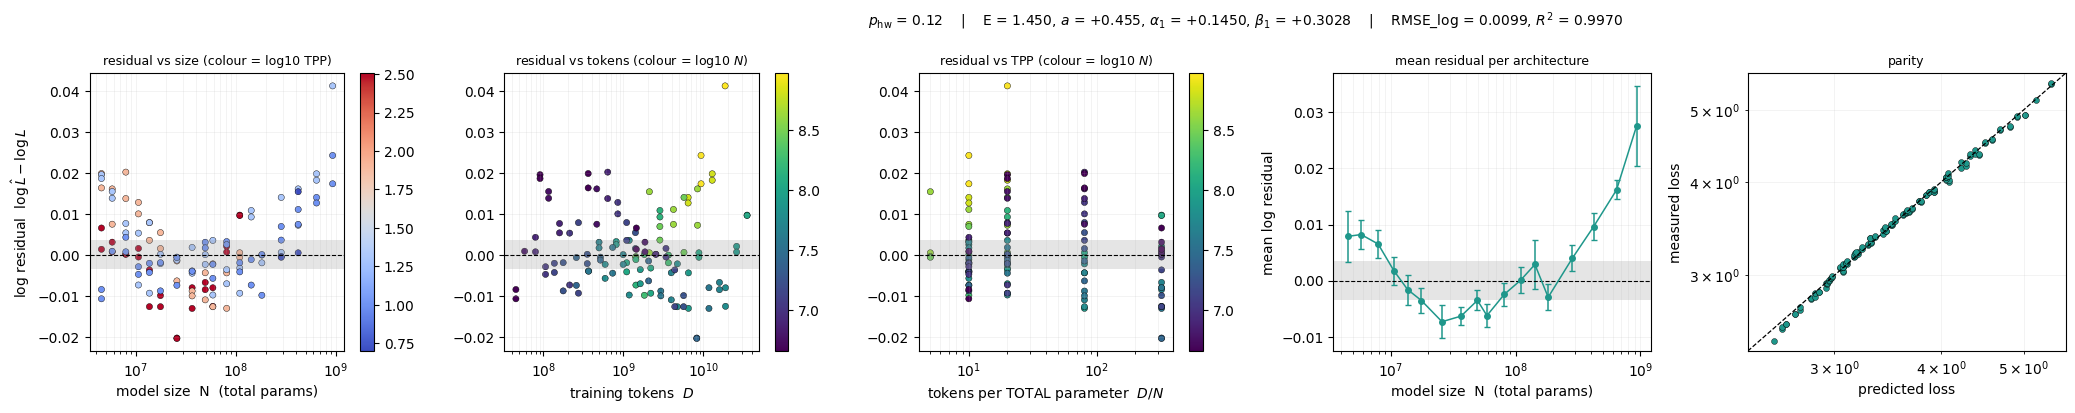

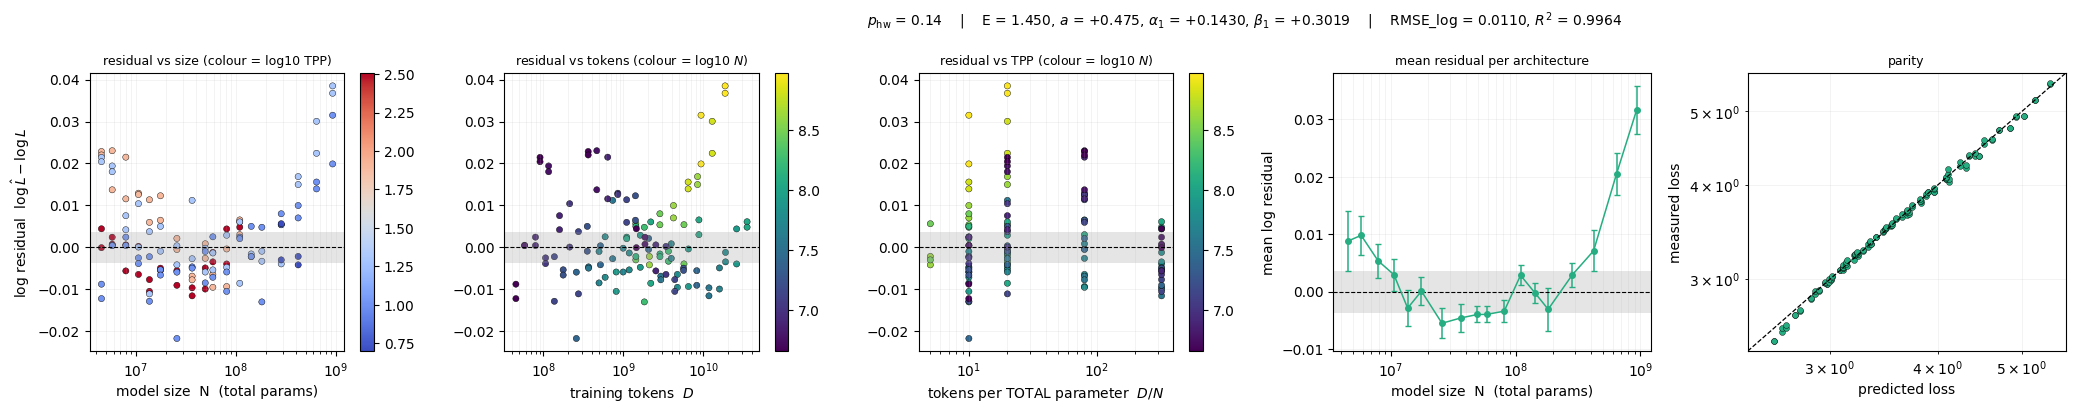

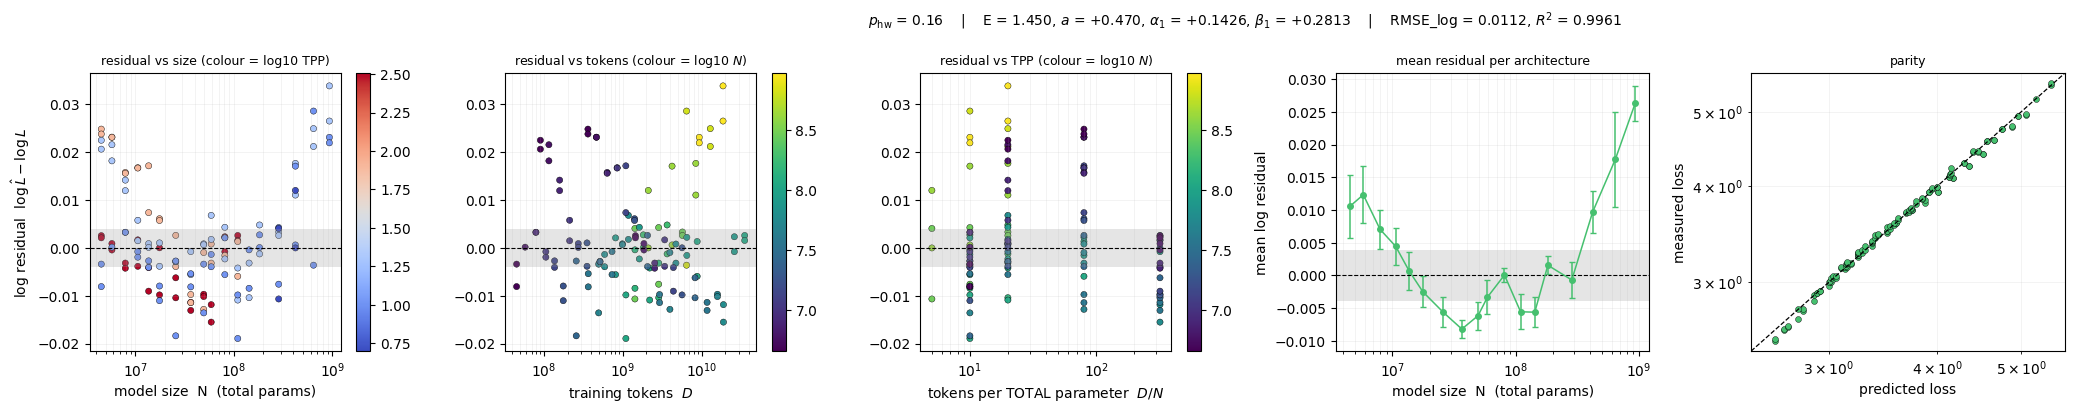

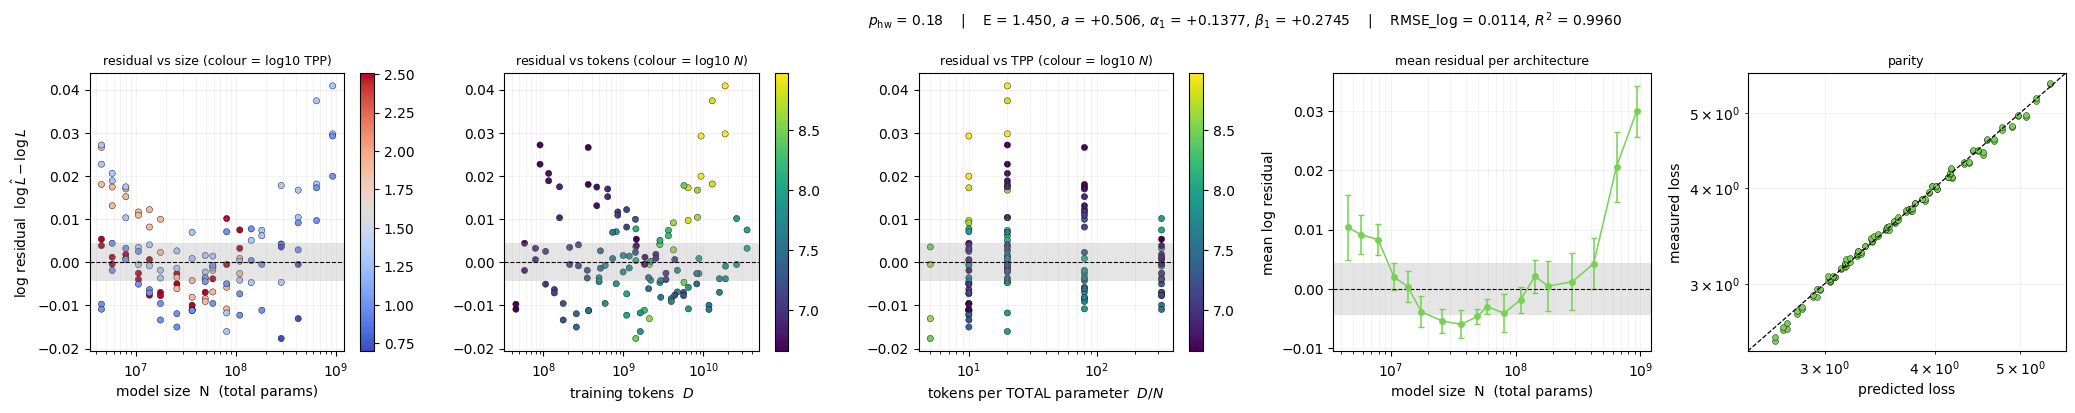

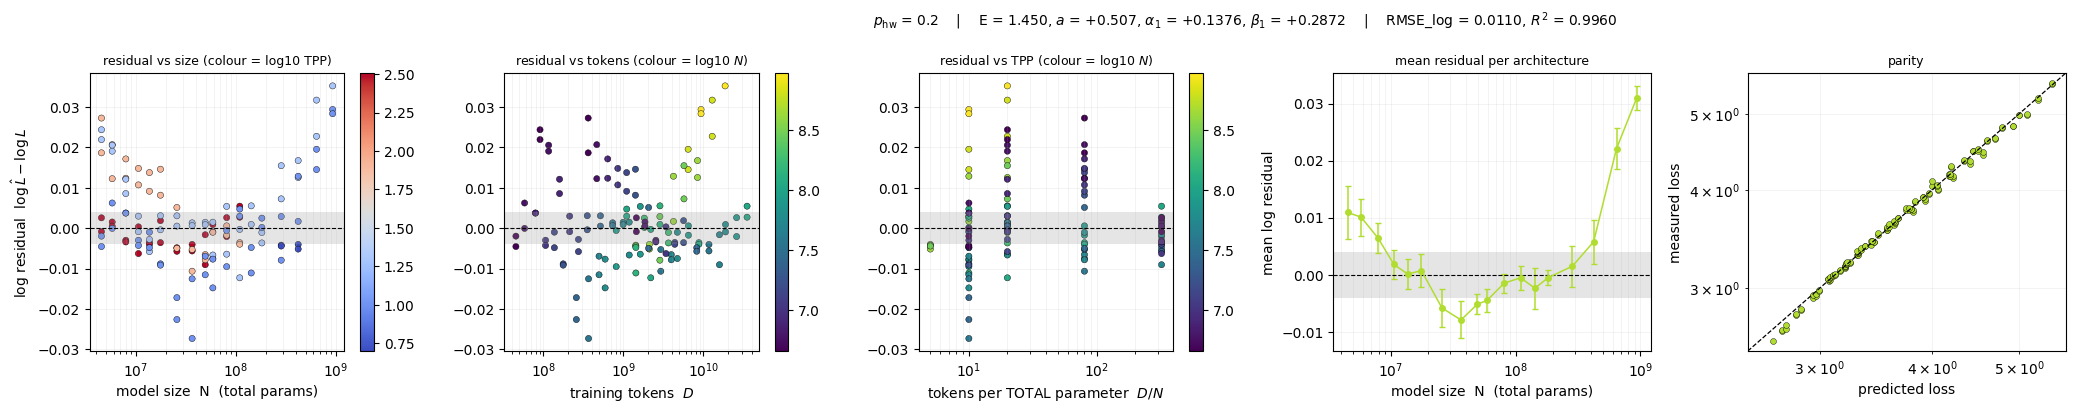

In [7]:
for p in sorted(arr):
    a, r, f = arr[p], res[p], fits[p]
    pred = f.predict(a["N"], a["D"])
    sig = run_sigma[p]      # the measured run-to-run floor -- eval noise INCLUDED (see cell 1)
    d = est.diagnostics(f, a["N"], a["D"], a["L"])

    fig, axs = plt.subplots(ncols=6, figsize=(25, 25/6))
    axs = axs.ravel()
    axs[5].set_visible(False)

    ax = axs[0]
    sc = ax.scatter(a["N"], r, c=np.log10(a["tpp"]), s=20, cmap="coolwarm", ec="k", lw=0.3)
    ax.axhspan(-sig, sig, color="0.6", alpha=0.25, lw=0)
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xscale("log"); ax.set_xlabel("model size  N  (total params)")
    ax.set_ylabel(r"log residual  $\log \hat L - \log L$")
    ax.set_title("residual vs size (colour = log10 TPP)", fontsize=9)
    plt.colorbar(sc, ax=ax); ax.grid(alpha=0.25, which="both", lw=0.4)

    ax = axs[1]
    sc = ax.scatter(a["D"], r, c=np.log10(a["N"]), s=20, cmap="viridis", ec="k", lw=0.3)
    ax.axhspan(-sig, sig, color="0.6", alpha=0.25, lw=0)
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xscale("log"); ax.set_xlabel("training tokens  $D$")
    ax.set_title("residual vs tokens (colour = log10 $N$)", fontsize=9)
    plt.colorbar(sc, ax=ax); ax.grid(alpha=0.25, which="both", lw=0.4)

    ax = axs[2]
    sc = ax.scatter(a["tpp"], r, c=np.log10(a["N"]), s=20, cmap="viridis", ec="k", lw=0.3)
    ax.axhspan(-sig, sig, color="0.6", alpha=0.25, lw=0)
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xscale("log"); ax.set_xlabel("tokens per TOTAL parameter  $D/N$")
    ax.set_title("residual vs TPP (colour = log10 $N$)", fontsize=9)
    plt.colorbar(sc, ax=ax); ax.grid(alpha=0.25, which="both", lw=0.4)

    ax = axs[3]
    x, m, e, _ = arch_means(p)
    ax.errorbar(x, m, yerr=e, fmt="o-", color=cohort_color[p], ms=4, lw=1.1, capsize=2)
    ax.axhspan(-sig, sig, color="0.6", alpha=0.25, lw=0)
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xscale("log"); ax.set_xlabel("model size  N  (total params)")
    ax.set_ylabel("mean log residual")
    ax.set_title("mean residual per architecture", fontsize=9)
    ax.grid(alpha=0.25, which="both", lw=0.4)

    ax = axs[4]
    ax.scatter(pred, a["L"], s=18, color=cohort_color[p], ec="k", lw=0.3)
    lim = [min(pred.min(), a["L"].min()) * 0.97, max(pred.max(), a["L"].max()) * 1.03]
    ax.plot(lim, lim, "k--", lw=0.9)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("predicted loss"); ax.set_ylabel("measured loss")
    ax.set_title("parity", fontsize=9)
    ax.grid(alpha=0.25, which="both", lw=0.4)

    _a2 = f"$\\alpha_2$ = {f.alpha2:+.4f}, " if f.alpha2 else ""
    fig.suptitle(f"$p_\\mathrm{{hw}}$ = {p:g}    |    E = {f.E:.3f}, $a$ = {f.a:+.3f}, "
                 f"$\\alpha_1$ = {f.alpha1:+.4f}, {_a2}$\\beta_1$ = {f.beta1:+.4f}    |    "
                 f"RMSE_log = {d['rmse_log']:.4f}, $R^2$ = {d['r2_log']:.4f}", fontsize=10)
    fig.tight_layout()
    plt.show()